# Surface Temperature Analysis - NASA GISTEMP 

## What Does GISTEMP Measure?

NASA GISTEMP provides estimates of global surface temperature anomalies based on:
- Land-based meteorological stations
- Sea surface temperature measurements
- Spatial interpolation to account for incomplete coverage

The dataset reports temperature anomalies, not absolute temperatures.
    
>Temperature anomaly = observed temperature − baseline climatology.

This allows:
- Cross-regional comparison
- Reduced bias from station-specific conditions
- Clearer detection of long-term change

## Spatial and Temporal Coverage

GISTEMP provides:
- Monthly and annual data
- Global mean temperature anomalies
- Gridded temperature anomaly maps
- Coverage extending back to the late 19th century (~1880)

Important characteristics:
- Early data is sparse
- Coverage improves significantly after ~1950
- Polar regions historically under-sampled

## Strengths and Limitations

Strengths:
- Long historical record (~140+ years)
- Global aggregation
- Transparent methodology
- Widely used in peer-reviewed research

Limitations:
- Sparse early station coverage
- Interpolation assumptions
- Changes in measurement technology over time
- Urban heat island corrections required

>Observational datasets are estimates, not direct thermometers of the planet.

## Accessing the dataset

NASA GISTEM provides various datasets for download directly at https://data.giss.nasa.gov/gistemp/

These files are available in both CSV and NetCDF format. 

For example, we can find the **global mean temperature anomaly dataset** by looking into *Global-mean monthly, seasonal, and annual means, 1880-present, updated through most recent month*

We can download the CSV file or access the dataset directly using **pandas** from the link:

In [1]:
# 
import pandas as pd

url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"

df_raw = pd.read_csv(url, skiprows=1)

df_raw.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-.25,-.10,-.17,-.11,-.22,-.19,-.11,-.15,-.24,-.23,-.18,-.18,***,***,-.13,-.17,-.21
1,1881,-0.21,-.15,.02,.04,.05,-.20,-.01,-.04,-.16,-.22,-.19,-.08,-.10,-.10,-.18,.04,-.08,-.19
2,1882,0.15,.13,.04,-.18,-.15,-.24,-.17,-.08,-.15,-.24,-.17,-.37,-.12,-.09,.07,-.10,-.16,-.19
3,1883,-0.30,-.37,-.13,-.19,-.18,-.07,-.08,-.14,-.22,-.11,-.25,-.12,-.18,-.20,-.35,-.17,-.10,-.19
4,1884,-0.14,-.09,-.37,-.40,-.34,-.35,-.31,-.28,-.27,-.25,-.34,-.31,-.29,-.27,-.11,-.37,-.31,-.29


### Gridded Climate Data in NetCDF Format

In addition to simple tabular datasets (such as CSV files), climate science often uses the **NetCDF (Network Common Data Form)** format to store large multidimensional datasets.

NetCDF files are commonly used in meteorology, climate science, and oceanography because they allow efficient storage of data with multiple dimensions such as:
- time
- latitude
- longitude

Unlike CSV tables, which typically store a single value per row, NetCDF datasets store **spatial fields evolving over time**. This makes them well suited for representing global observations and climate model output.

For example, we can look into the **NASA GISTEMP Land-Ocean Temperature Index** dataset, which provides gridded temperature anomaly values across the Earth's surface, which can be found as *NASA GISTEMP Land-Ocean Temperature Index (ERSSTv5, 1200 km smoothing)*

Key characteristics of this dataset:
- Temperature anomalies relative to a baseline climate period
- Monthly global coverage
- Grid resolution of 2° latitude × 2° longitude
- Observations from 1880 to present
- Includes both land air temperatures and sea surface temperatures

The 1200 km smoothing refers to the spatial interpolation applied to temperature observations to estimate values in regions with sparse measurements.

In Python, NetCDF files are commonly accessed using the **xarray** library, which provides convenient tools for working with multidimensional labeled arrays.

For this, you might need to install **xarray** and **netCDF4** libraries, which can be done:
- If you are using a standard Python environment:
> pip install xarray netCDF4
- If you are using Anaconda / Miniconda environment:
> conda install -c conda-forge xarray netcdf4
- If using Google Colab:
> !pip install xarray netCDF4


In [2]:
# Loading the dataset
import xarray as xr
import numpy as np

ds = xr.open_dataset("gistemp1200_GHCNv4_ERSSTv5.nc")

ds

<xarray.Dataset> Size: 114MB
Dimensions:      (lat: 90, lon: 180, time: 1753, nv: 2)
Coordinates:
  * lat          (lat) float32 360B -89.0 -87.0 -85.0 -83.0 ... 85.0 87.0 89.0
  * lon          (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
  * time         (time) datetime64[ns] 14kB 1880-01-15 1880-02-15 ... 2026-01-15
Dimensions without coordinates: nv
Data variables:
    time_bnds    (time, nv) datetime64[ns] 28kB ...
    tempanomaly  (time, lat, lon) float32 114MB ...
Attributes:
    title:        GISTEMP Surface Temperature Analysis
    institution:  NASA Goddard Institute for Space Studies
    source:       http://data.giss.nasa.gov/gistemp/
    Conventions:  CF-1.6
    history:      Created 2026-02-09 07:49:10 by SBBX_to_nc 2.0 - ILAND=1200,...

In [3]:
# Inspect dataset structure
print(ds)

# Show coordinates
print(ds.coords)

# Show available variables
print(ds.data_vars)

<xarray.Dataset> Size: 114MB
Dimensions:      (lat: 90, lon: 180, time: 1753, nv: 2)
Coordinates:
  * lat          (lat) float32 360B -89.0 -87.0 -85.0 -83.0 ... 85.0 87.0 89.0
  * lon          (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
  * time         (time) datetime64[ns] 14kB 1880-01-15 1880-02-15 ... 2026-01-15
Dimensions without coordinates: nv
Data variables:
    time_bnds    (time, nv) datetime64[ns] 28kB ...
    tempanomaly  (time, lat, lon) float32 114MB ...
Attributes:
    title:        GISTEMP Surface Temperature Analysis
    institution:  NASA Goddard Institute for Space Studies
    source:       http://data.giss.nasa.gov/gistemp/
    Conventions:  CF-1.6
    history:      Created 2026-02-09 07:49:10 by SBBX_to_nc 2.0 - ILAND=1200,...
Coordinates:
  * lat      (lat) float32 360B -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
  * time     (time) datetime64[ns] 14kB 1880-01-15 1880

In [4]:
# Inspect the temperature anomaly variable
ds['tempanomaly']

<xarray.DataArray 'tempanomaly' (time: 1753, lat: 90, lon: 180)> Size: 114MB
[28398600 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 360B -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
  * time     (time) datetime64[ns] 14kB 1880-01-15 1880-02-15 ... 2026-01-15
Attributes:
    long_name:     Surface temperature anomaly
    units:         K
    cell_methods:  time: mean

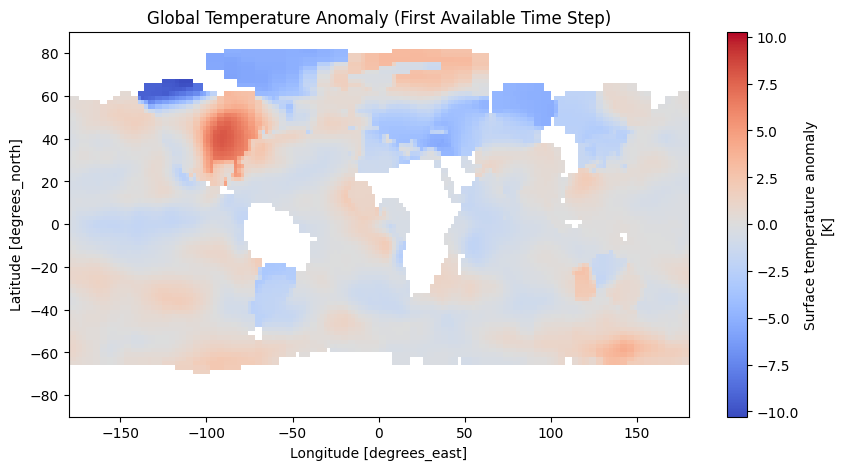

In [6]:
# Example plot global temperature anomaly map
import matplotlib.pyplot as plt

# Select the first time step
temp0 = ds['tempanomaly'].isel(time=0)

plt.figure(figsize=(10,5))
temp0.plot(cmap="coolwarm")
plt.title("Global Temperature Anomaly (First Available Time Step)")
plt.show()

## Student tasks:
1. Select, inspect, and analyze a NASA GISTEMP dataset.
- What are the columns?
- What is the time range?
- Are there missing values?

2. Plot the temperature record
- Create a line plot of annual temperature anomaly versus year.
- Add labels and title.

3. Detect the trend
- Compute a linear trend line.
- Estimate whether the trend is positive or negative.
- Identify periods of faster warming or temporary slowdown.

4. Interpret the result
- What is the difference between short-term variability and long-term climate trend?
- Does the plot suggest climate change?
- Why is a single cold year not evidence against long-term warming?
- Evaluate common misconceptions about climate change and discuss the scientific evidence
- identify climate change impacts across different regions (heat waves in Europe, drought in Africa, floods in Asia) and present findings